# Assignment 5: Stock Price Predictions

**Data:**

Historical stock price data on US-based stocks, last updated in 2017. The dataset is available at Huge Stock Market Dataset | Kaggle and is provided by Boris Marjanovic. A list of stock ticker symbols is available at List of All Stock Ticker Symbols - Stock Analysis, to help identify the name of the stock from the txt file name.

**Problem Statement:**

An investment company is interested in learning about the potential profit in frequent buy/sell stock transactions. You are tasked with developing a time sequence model to predict the price two days ahead based on recent prices. Choose four (or more) of the data files for training and a separate two for validation. Once the model is finalized, demonstrate how well your model makes predictions by using two other data files for testing.

# 1. Data
## 1.1 Load Data
Select four (or more) of the data files in stocks.zip to use as training data, two others for validation, and two others for testing.

In [1]:
import pandas as pd
import numpy as np
import os
# Global Parameters
LOOKBACK = 20
# Importing the training datasets
train_files = [
    'stock_price_files/nflx.us.txt',
    'stock_price_files/amzn.us.txt',
    'stock_price_files/tsla.us.txt',
    'stock_price_files/msft.us.txt'
]
# Importing the validation datasets
val_files = [
    'stock_price_files/aapl.us.txt',  
    'stock_price_files/fb.us.txt'
]
# Importing the test datasets
test_files = [
    'stock_price_files/googl.us.txt',
    'stock_price_files/nvda.us.txt'
]
# Assigning the dataframes to lists for training, validation, and testing
dfs_train = [pd.read_csv(file) for file in train_files]
dfs_val = [pd.read_csv(file) for file in val_files]
dfs_test = [pd.read_csv(file) for file in test_files]

for df in dfs_train:
    df["Date"] = pd.to_datetime(df["Date"])
    df.sort_values("Date", inplace=True)
    df.reset_index(drop=True, inplace=True)

for df in dfs_val:
    df["Date"] = pd.to_datetime(df["Date"])
    df.sort_values("Date", inplace=True)
    df.reset_index(drop=True, inplace=True)

for df in dfs_test:
    df["Date"] = pd.to_datetime(df["Date"])
    df.sort_values("Date", inplace=True)
    df.reset_index(drop=True, inplace=True)


## 1.2 Ploting Closing Prices
Plot the closing price in each data file using dates to label the x-axis.

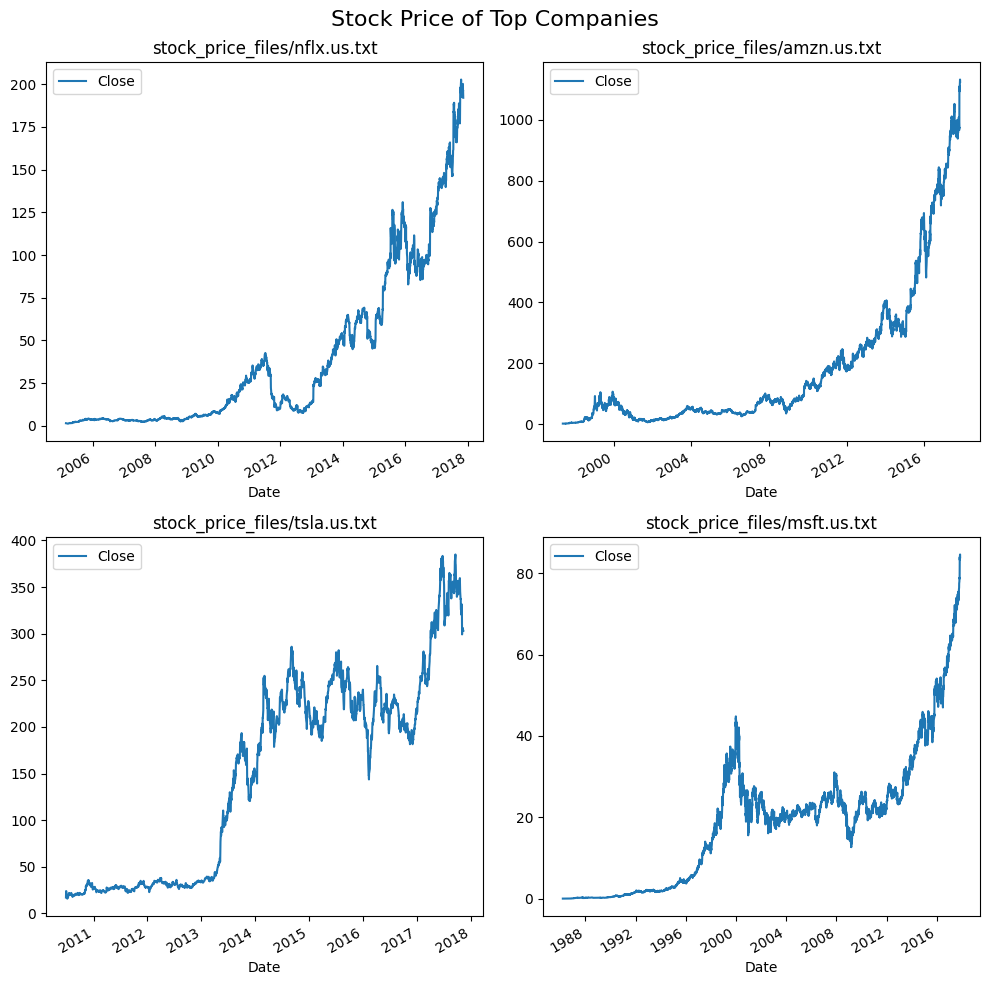

In [2]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(2, 2, figsize=(10, 10))
for (i,df),(x,y) in zip(enumerate(dfs_train),[(0,0),(0,1),(1,0),(1,1)]):
    df.plot("Date", "Close", ax=ax[x, y])
    ax[x, y].set_title(f"{train_files[i]}")
    plt.tight_layout()
plt.suptitle("Stock Price of Top Companies", fontsize=16)
plt.tight_layout()
plt.show()


## 1.3 2-Days Forecast Function
Create a function that loads the closing prices from a data file into input and label numpy arrays that are appropriate for training time sequence models to predict a price two days into the future, using a lookback value of your choice.

In [3]:
def make_2day_forecast_arrays(df, lookback=20, horizon=2):
    close = df["Close"].to_numpy(dtype=np.float32)
    X, y = [], []
    # last index in each input window = i + lookback - 1
    # target index = i + lookback - 1 + horizon
    max_start = len(close) - lookback - horizon + 1

    for i in range(max_start):
        X.append(close[i : i + lookback])
        y.append(close[i + lookback - 1 + horizon])

    X = np.array(X, dtype=np.float32)              # shape: (samples, lookback)
    y = np.array(y, dtype=np.float32).reshape(-1, 1)  # shape: (samples, 1) -> 2D labels
    return X, y


## 1.4 Transforming all the datasets
Use the function created in the previous step to load all of the data files into 2d numpy arrays. Concatenate the input arrays and the label arrays. After this step, you should have a single array of sequences for inputs, and a single array of labels. Use scaling if you like as well, but be careful with you how you implement it, particularly with calculation of RMSE.


In [4]:
from sklearn.preprocessing import MinMaxScaler
def concatenate_dfs_to_arrays(dfs):
    x_1_train_list, y_1_train_list = [], []

    for df in dfs:
        scaler = MinMaxScaler()
        df['Close'] = scaler.fit_transform(df[['Close']])
        
        x, y = make_2day_forecast_arrays(df)
        x_1_train_list.append(x)
        y_1_train_list.append(y)

    # Concatenate
    X_1_train = np.concatenate(x_1_train_list, axis=0)
    y_1_train = np.concatenate(y_1_train_list, axis=0)
    return X_1_train, y_1_train

x_1_train, y_1_train = concatenate_dfs_to_arrays(dfs_train)
x_1_val, y_1_val = concatenate_dfs_to_arrays(dfs_val)
x_1_test, y_1_test = concatenate_dfs_to_arrays(dfs_test)

# 2. Modeling
## 2.1 Model Compilation
Create and compile a time sequence model using tf.keras.Sequential. Use at least one Conv1d layer, one SimpleRNN layer, and one Dropout layer. Use mean_squared_error for the loss.

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Reshape, Conv1D, SimpleRNN, Dropout, Dense, Activation

model_1 = Sequential(name="base_model")
model_1.add(Reshape((LOOKBACK, 1), input_shape=(LOOKBACK,)))
model_1.add(Conv1D(filters=5, kernel_size=3, activation='relu'))
model_1.add(SimpleRNN(32))
model_1.add(Dropout(0.2))          
model_1.add(Dense(1))
model_1.add(Activation('linear'))

# Compile the model
model_1.compile(optimizer='adam', loss='mean_squared_error')
model_1.summary()

Model: "base_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 reshape (Reshape)           (None, 20, 1)             0         
                                                                 
 conv1d (Conv1D)             (None, 18, 5)             20        
                                                                 
 simple_rnn (SimpleRNN)      (None, 32)                1216      
                                                                 
 dropout (Dropout)           (None, 32)                0         
                                                                 
 dense (Dense)               (None, 1)                 33        
                                                                 
 activation (Activation)     (None, 1)                 0         
                                                                 
Total params: 1,269
Trainable params: 1,269
Non-trainabl

## 2.2 Train and Record Traning Loss
Train the model on the training data without using a validation split. Calculate and record the training loss.

In [7]:
history_1 = model_1.fit(
    x_1_train, y_1_train,
    epochs=20,
    batch_size=32,
    verbose=1
    # no validation_split — assignment explicitly says not to use it
)

train_loss_1 = history_1.history['loss'][-1]
print(f"Final Training Loss (MSE): {train_loss_1:.6f}")

Epoch 1/20
566/566 [==============================] - 2s 3ms/step - loss: 0.0034
Epoch 2/20
566/566 [==============================] - 2s 3ms/step - loss: 9.7038e-04
Epoch 3/20
566/566 [==============================] - 2s 4ms/step - loss: 8.0074e-04
Epoch 4/20
566/566 [==============================] - 2s 4ms/step - loss: 7.3778e-04
Epoch 5/20
566/566 [==============================] - 2s 4ms/step - loss: 6.6840e-04
Epoch 6/20
566/566 [==============================] - 2s 3ms/step - loss: 6.1877e-04
Epoch 7/20
566/566 [==============================] - 1s 3ms/step - loss: 5.9985e-04
Epoch 8/20
566/566 [==============================] - 1s 3ms/step - loss: 5.9061e-04
Epoch 9/20
566/566 [==============================] - 1s 2ms/step - loss: 5.6110e-04
Epoch 10/20
566/566 [==============================] - 1s 2ms/step - loss: 5.7438e-04
Epoch 11/20
566/566 [==============================] - 1s 3ms/step - loss: 5.8180e-04
Epoch 12/20
566/566 [==============================] - 2s 3ms/step 

## 2.3 Validate and Plot Predictions
Use the model to make predictions on the validation data. Calculate and record the validation loss. Create plots of the validation data that show the true price as well as the model predictions, with date or index number along the x-axis.

304/304 [==============================] - 1s 2ms/step
 Validation Loss (MSE): 0.000164
Validation RMSE:       0.012820


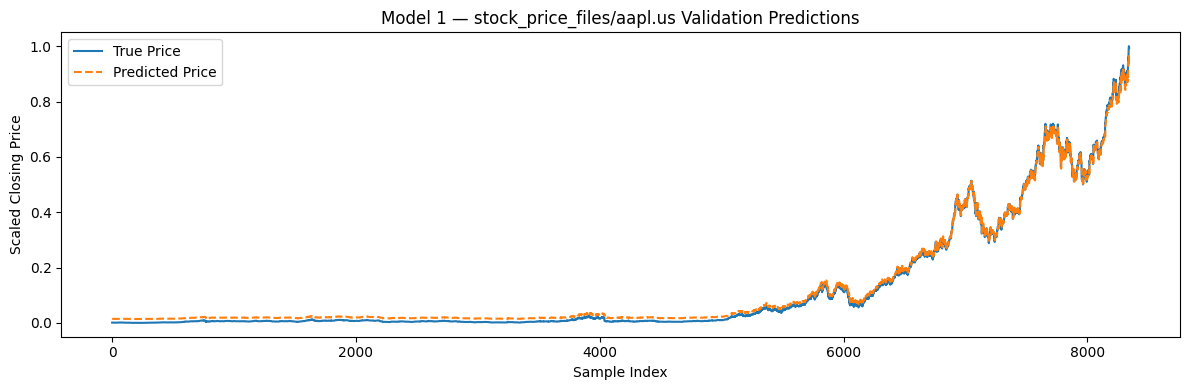

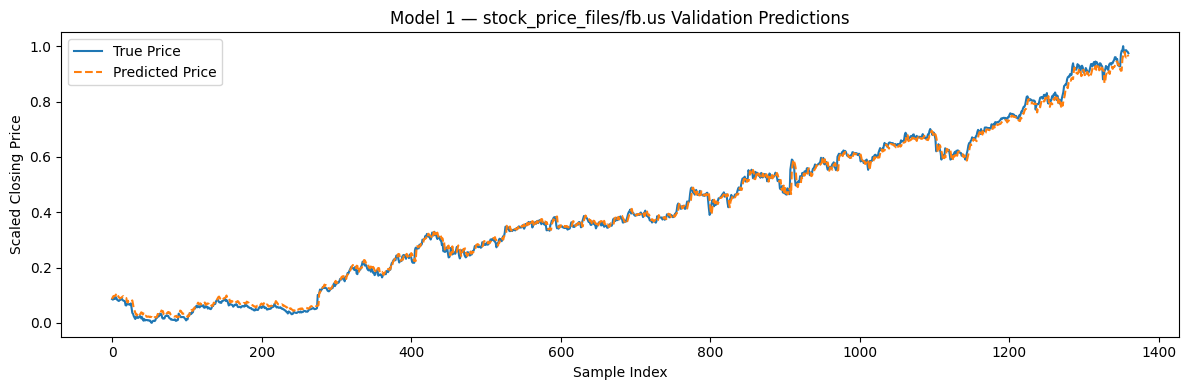

In [8]:
# Get predictions on validation set
from sklearn.metrics import mean_squared_error


y_pred_1 = model_1.predict(x_1_val)

# Calculate validation loss
val_loss_1 = mean_squared_error(y_1_val, y_pred_1)
print(f" Validation Loss (MSE): {val_loss_1:.6f}")
print(f"Validation RMSE:       {np.sqrt(val_loss_1):.6f}")

# Plot predictions vs true values per validation stock
def plot_predictions(y_true, y_pred, val_files, lookback=LOOKBACK, horizon=2):
    """
    Plots true vs predicted prices for each validation stock separately.
    Uses index along x-axis since sequences are concatenated and dates are lost.
    """
    # Figure out how many samples came from each val file
    # so we can split the concatenated arrays back apart for plotting
    split_sizes = []
    for fname in val_files:
        df = pd.read_csv(fname, parse_dates=['Date'])
        n = len(df) - lookback - horizon + 1
        split_sizes.append(n)

    splits_X = np.split(y_true, np.cumsum(split_sizes[:-1]))
    splits_y = np.split(y_pred, np.cumsum(split_sizes[:-1]))

    for i, fname in enumerate(val_files):
        ticker = fname.replace('.txt', '')
        true_vals = splits_X[i].flatten()
        pred_vals = splits_y[i].flatten()

        plt.figure(figsize=(12, 4))
        plt.plot(true_vals, label='True Price', linewidth=1.5)
        plt.plot(pred_vals, label='Predicted Price', linewidth=1.5, linestyle='--')
        plt.title(f'Model 1 — {ticker} Validation Predictions')
        plt.xlabel('Sample Index')
        plt.ylabel('Scaled Closing Price')
        plt.legend()
        plt.tight_layout()
        plt.show()

plot_predictions(y_1_val, y_pred_1, val_files)

## 2.4 Trying different models
Revisit the previous steps to make at least three models in total by changing architecture and hyperparameters.
Once you are finished altering hyperparameters, present neatly the training and validation loss along with the plots for